In [1]:
import pandas as pd

In [2]:
df=pd.read_csv("../data/Titanic-Dataset.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [4]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [5]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [6]:
df["Age"].describe()

count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: Age, dtype: float64

# Feature construction 

 ## 1.handling missing values

In [7]:
df["Age"]=df["Age"].fillna(df["Age"].median())

In [8]:
df["Embarked"]=df["Embarked"].fillna(df["Embarked"].mode()[0])

In [9]:
df["Cabin"] = df["Cabin"].astype("object").fillna("Unknown")

In [10]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64

## 2. Handling categorical data

In [11]:
df.select_dtypes(include=["object", "category"]).columns

Index(['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked'], dtype='object')

In [12]:
df["Embarked"].unique()

array(['S', 'C', 'Q'], dtype=object)

In [13]:
df["Sex"] = df["Sex"].map({
    "male": 0,
    "female": 1
})

In [14]:
df = pd.get_dummies(
    df,
    columns=["Embarked"],
    drop_first=True
)

In [15]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,Unknown,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,C85,False,False
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,Unknown,False,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,C123,False,True
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,Unknown,False,True


## 3.Outlier Detection

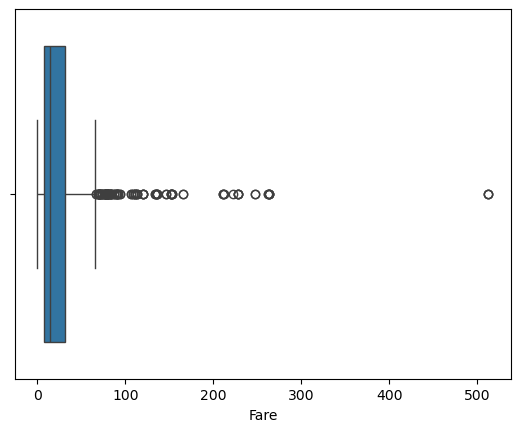

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.boxplot(x=df["Fare"])
plt.show()

In [20]:
Q1 = df["Fare"].quantile(0.25)
Q3 = df["Fare"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

In [21]:
outliers = df[
    (df["Fare"] < lower) |
    (df["Fare"] > upper)
]

outliers

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked_Q,Embarked_S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,C85,False,False
27,28,0,1,"Fortune, Mr. Charles Alexander",0,19.0,3,2,19950,263.0000,C23 C25 C27,False,True
31,32,1,1,"Spencer, Mrs. William Augustus (Marie Eugenie)",1,28.0,1,0,PC 17569,146.5208,B78,False,False
34,35,0,1,"Meyer, Mr. Edgar Joseph",0,28.0,1,0,PC 17604,82.1708,Unknown,False,False
52,53,1,1,"Harper, Mrs. Henry Sleeper (Myna Haxtun)",1,49.0,1,0,PC 17572,76.7292,D33,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
846,847,0,3,"Sage, Mr. Douglas Bullen",0,28.0,8,2,CA. 2343,69.5500,Unknown,False,True
849,850,1,1,"Goldenberg, Mrs. Samuel L (Edwiga Grabowska)",1,28.0,1,0,17453,89.1042,C92,False,False
856,857,1,1,"Wick, Mrs. George Dennick (Mary Hitchcock)",1,45.0,1,1,36928,164.8667,Unknown,False,True
863,864,0,3,"Sage, Miss. Dorothy Edith ""Dolly""",1,28.0,8,2,CA. 2343,69.5500,Unknown,False,True
